In [3]:
import numpy as np
import matplotlib.pyplot as plt

from alter_surf.hamiltonian_DLKK import H_DLKK_3D_MF
from alter_surf.mean_field import hartree_fock

In [5]:
Hparam = dict(len_z=20,delta=0.4, tp=0.3, tz=1, U=10, filling=0.5, PBC= False)
initial_parameters = dict(initial_m=(-1)**np.arange(Hparam['len_z'])/4, initial_n=Hparam['filling']*np.ones(Hparam['len_z']))

m_values, n_values = hartree_fock(Hparam,initial_parameters, 40, Lq=20, tol_mdiff=1e-3,mixing_proportion=0.4)


Avg:-0.00, Stag. avg:0.45, diff: 0.000242:  22%|██▎       | 9/40 [00:06<00:23,  1.33it/s]


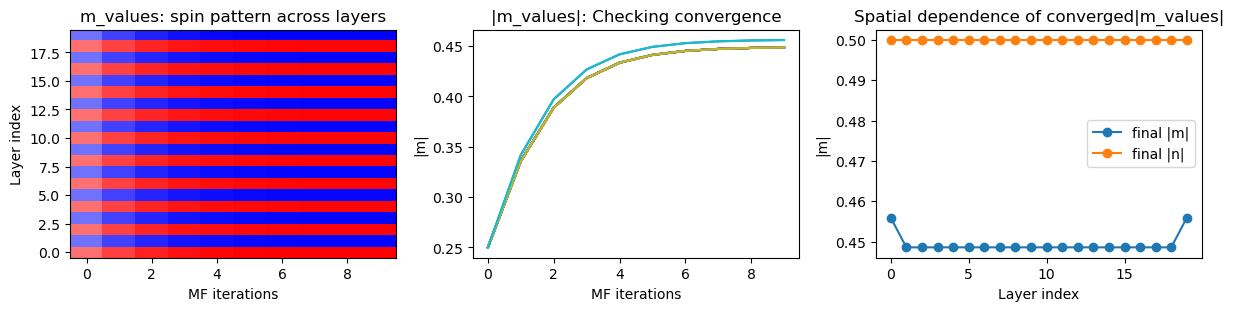

In [6]:
fig, axs = plt.subplots(1,3, figsize=(12,3), constrained_layout=True)

axs[0].set_title('m_values: spin pattern across layers')
axs[0].set_xlabel('MF iterations')
axs[0].set_ylabel('Layer index')
axs[0].imshow(m_values.T, aspect='auto', cmap='bwr',origin='lower', vmin=-m_values.max(), vmax=m_values.max())

axs[1].set_title('|m_values|: Checking convergence')
axs[1].set_xlabel('MF iterations')
axs[1].set_ylabel('|m|')
axs[1].plot(np.abs(m_values))

axs[2].set_title('Spatial dependence of converged|m_values|')
axs[2].set_xlabel('Layer index')
axs[2].set_ylabel('|m|')
axs[2].plot(np.abs(m_values[-1]),'-o',label='final |m|')
axs[2].plot(np.abs(n_values[-1]),'-o',label='final |n|')
axs[2].legend()